# Traversal order/methods
Traversal is the process of visiting each `Node` in a tree exactly once in a defined order. Different traversal orders are useful for efficient calculations, searches, and tree algorithms.

This page introduces the main traversal strategies in `toytree`, then focuses on the cached `idxorder` traversal used by `ToyTree`. Understanding `idxorder` explains node `idx` labels and why selecting nodes by index is fast and intuitive, as also used in the [Node Query/Selection section](core-query).

<div class="admonition tip">
  <p class="admonition-title">Take Home</p>
  <p>
      The main idea on this page is <code>idxorder</code>. It is the cached traversal behind node <code>idx</code> labels, so once you understand it, selecting tips, internal nodes, and slices of nodes becomes much easier.
  </p>
</div>

In [1]:
import toytree

In [2]:
# an example tree
tree = toytree.rtree.unittree(8, seed=123)

## Why traverse?
A `ToyTree` contains connected `Node` objects arranged hierarchically. Even if you store those nodes in a list or dictionary, you still need some linear order to visit them, and different tasks benefit from different orders.

**A traversal algorithm is a consistent set of rules for visiting each `Node` exactly once.**

Some traversals are useful when parent values depend on children, others when children depend on parents, and others when you want to stop early after finding a target. Many statistics, model-fitting methods, and search algorithms on trees depend on one of these patterns.

`ToyTree.traverse()` is a generator that yields nodes one at a time in the requested order.

In [3]:
# traverse() is a generator function
tree.traverse(strategy="levelorder")

<generator object ToyTree.traverse at 0x795620e49e50>

In [4]:
# unpacking the generator returns every Node visited once
list(tree.traverse("levelorder"))

[<Node(idx=14)>,
 <Node(idx=9)>,
 <Node(idx=13)>,
 <Node(idx=0, name='r0')>,
 <Node(idx=8)>,
 <Node(idx=10)>,
 <Node(idx=12)>,
 <Node(idx=1, name='r1')>,
 <Node(idx=2, name='r2')>,
 <Node(idx=3, name='r3')>,
 <Node(idx=4, name='r4')>,
 <Node(idx=5, name='r5')>,
 <Node(idx=11)>,
 <Node(idx=6, name='r6')>,
 <Node(idx=7, name='r7')>]

## Traversal strategies
Below are the main traversal strategies in `toytree`: `levelorder`, `preorder`, `postorder`, and `idxorder`. The helper function below draws a tree and labels each node by its position in the chosen traversal.

In [8]:
def get_traversal_drawing(tree, strategy):
    """Return a tree drawing canvas showing a traversal strategy"""
    # create map of {node: int} in levelorder traversal
    order = {j: i for (i, j) in enumerate(tree.traverse(strategy))}

    # set as data to the tree
    tree.set_node_data(feature=strategy, data=order, inplace=True)

    # draw the tree showing the 'levelorder' feature on nodes
    c, a, m = tree.draw(
        layout="d", node_sizes=18, node_labels=strategy, node_mask=False
    )

    # add label
    a.label.text = f'"{strategy}" traversal'
    return c

### levelorder (root to tips)
A levelorder traversal, also called breadth-first search (BFS), starts at the root and visits nodes one depth level at a time before moving deeper. Here depth means number of nodes, not branch length. In `toytree`, nodes within a level are visited left to right. Its main advantage is that parents are always visited before children.

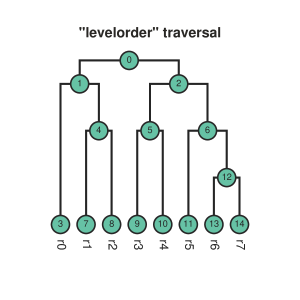

In [10]:
get_traversal_drawing(tree, "levelorder")

### preorder (root to tips)
A preorder traversal is a [depth-first search](https://en.wikipedia.org/wiki/Depth-first_search). It starts at the root and follows each subtree as far as possible before backtracking. In `toytree`, the default order is NLR: node, left subtree, right subtree. Like levelorder, it visits each parent before its children, but it explores deep branches sooner, which matters if you may stop once a target node is found.

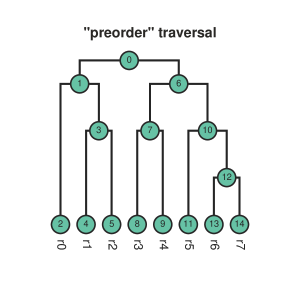

In [11]:
get_traversal_drawing(tree, "preorder")

### postorder (tips to root)
A postorder traversal is also depth-first, but it yields nodes after visiting their descendants. In `toytree`, the default order is LRN: left subtree, right subtree, node. This means children are always visited before their parent, which is useful when parent values depend on child values, such as likelihood, parsimony, ancestral-state, or node-height calculations.

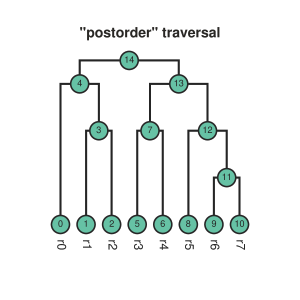

In [12]:
get_traversal_drawing(tree, "postorder")

### idxorder (tips to root)
`idxorder` is a custom traversal used by `toytree`. It visits all tip nodes from left to right first, then visits internal nodes in postorder. You can think of it as tips-first-then-postorder. Like postorder, internal nodes are visited only after their children.

This is especially convenient for phylogenetic trees because tips are often the named samples users care about most. It also means the first `ntips` positions are always the tips, which is why tip selection by index is so simple in `ToyTree`.

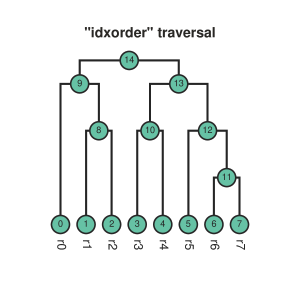

In [13]:
get_traversal_drawing(tree, "idxorder")

## Using a cached traversal
Traversal is useful, but repeated traversals are not always the fastest way to access nodes.

If a tree has not changed, it is often better to cache a traversal-derived view of the structure and reuse it. Looking up nodes from cached data is much faster than walking the whole tree again.

This is a key property of the `ToyTree` class. It stores a cached `idxorder` traversal and updates that cache when the tree structure is modified. **That cache is the source of node `idx` labels.** Because of this, tips, internal nodes, and full-node slices can be accessed quickly without running a fresh traversal each time.

In [14]:
# node idx 0 represents the first node in an idxorder traversal
tree[3]

<Node(idx=3, name='r3')>

In [15]:
# node idx 10 represents the 11th node in an idxorder traversal
tree[10]

<Node(idx=10)>

### Speed Comparison
Here is a simple example: access the names of every leaf node in a large tree. The first approach reads tips directly from the cached `idxorder`; the second performs a new traversal. Both are fast, but the cached approach is about 10X faster. The difference is modest here, but it matters in code that repeats the operation many times.

In [16]:
bigtree = toytree.rtree.rtree(ntips=300)

In [17]:
%%timeit
# select tip nodes from the idxorder cache
[i.name for i in bigtree[: bigtree.ntips]]

27.8 μs ± 3.99 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [18]:
%%timeit
# perform a new traversal to visit each node
names = []
for node in bigtree.traverse(strategy="idxorder"):
    if node.is_leaf():
        names.append(node.name)

210 μs ± 5.57 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Common traversals
Below are common snippets for iterating over all nodes or common subsets:

### iterate over all nodes

In [19]:
# trees are iterable and return nodes in idxorder
for node in tree:
    pass

# same as above
for node in tree[:]:
    pass

# nodes can be indexed using their idxorder idx labels
for idx in range(tree.nnodes):
    node = tree[idx]

# to iterate idxorder in reverse (root to tips)
for node in tree[::-1]:
    pass

### iterate over leaf nodes
The patterns below iterate over leaf nodes efficiently.

In [20]:
# for tip nodes
for idx in range(tree.ntips):
    pass

# for tip nodes
for node in tree[: tree.ntips]:
    pass

# for tip nodes
for node in tree:
    if not node.is_leaf():
        pass

# tips in reverse order of how they will be plotted
for node in tree[: tree.ntips][::-1]:
    pass

# tips in reverse order of how they will be plotted
for node in tree[: tree.ntips : -1]:
    pass

### iterate over internal nodes
The patterns below iterate over internal nodes efficiently.

In [21]:
# for internal nodes
for idx in range(tree.ntips, tree.nnodes):
    pass

# for internal nodes
for node in tree[tree.ntips : tree.nnodes]:
    pass

# for internal nodes
for node in tree[:]:
    if not node.is_leaf():
        pass

# for reverse order: root to last internal
for idx in range(tree.nnodes - 1, tree.ntips - 1, -1):
    node = tree[idx]

# for reverse order: root to last internal
for node in tree[tree.nnodes : tree.ntips : -1]:
    pass